# Assignment: Blockchain Data Scraping & Analysis

**Tools: `Python`, `Jupyter Notebook`, `BeautifulSoup`, `Selenium`, `pandas`, `matplotlib`**

### Part 1: BeautifulSoup (CoinGecko)
Using what you learned from scraping CoinGecko:
Scrape the top 50 coins from CoinGecko and save the raw data to a CSV
Clean the numeric columns (price, market cap, volume, % changes)
**Answer these questions using pandas:**
- Which coin had the biggest 24h gain?
- Which coin had the biggest 24h loss?
- What is the total market cap of the top 50 coins combined?
- How many coins are down over 7 days?
Create two matplotlib charts of your choice that tell a story about the data. Each chart must have a title, labelled axes.

### Part 2: Selenium (Bitcoin Treasuries)
Using what you learned from scraping bitcointreasuries.net:
- Scrape the public companies page instead of private companies and save to CSV
- Compare it to the private companies data already scraped:
- Which sector (public vs private) holds more Bitcoin in total?
- How many companies appear in both lists? (Hint: compare the Name column)
- Which country has the most companies holding Bitcoin across both lists combined?
- Create one chart that visually compares public vs private company holdings in a way that is clear and easy to read



In [3]:
#importing needed libraries

import time

# HTTPS and HTML parsing
import requests
from bs4 import BeautifulSoup

#browser automation (selenium)
from selenium import webdriver #this is used to control the browser and perform actions like clicking, typing, etc.
from selenium.webdriver.chrome.service import Service #this is used to configure chrome webdriver
from selenium.webdriver.chrome.options import Options #this is used to configure chrome options and behaviour (managing starting and running of the browser)
from selenium.webdriver.common.by import By #this is used to specify how to locate elements on the webpage
from selenium.webdriver.support.ui import WebDriverWait #this is used to wait for certain conditions to be met before proceeding with the script
from selenium.webdriver.support import expected_conditions as EC #this is used to specify the conditions to wait for (e.g., presence of an element, visibility of an element, etc.)
from webdriver_manager.chrome import ChromeDriverManager #this is used to automatically manage the chromedriver binary and version compatibility with the installed Chrome browser

# data handling
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Configuring chrome options {Launch a headless browser}
chrome_options = Options()
chrome_options.add_argument("--headless") #this option allows us to run the browser in headless mode (without opening a visible window)
chrome_options.add_argument("--no-sandbox") #this option is used to disable the sandbox security feature (useful in certain environments like Docker)
chrome_options.add_argument("--disable-dev-shm-usage") #this option is used to avoid issues with limited shared memory in certain environments (like Docker)
chrome_options.add_argument("--disable-gpu") #this option is used to disable GPU hardware acceleration and is often necessary when running in headless mode to avoid issues with rendering
chrome_options.add_argument("--window-size=1920,1080") #this option sets the window size for the headless browser (important for ensuring that elements are rendered correctly and can be interacted with)

# A realistic User-Agent prevents some anti-bot measures that block requests from scripts. 
chrome_options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/122.0.0.0 Safari/537.36"
)

service = Service(ChromeDriverManager().install()) #this line sets up the ChromeDriver service using webdriver_manager to automatically handle the driver installation and version compatibility with the installed Chrome browser
driver = webdriver.Chrome(service=service, options=chrome_options) #this line initializes the Chrome WebDriver with the specified service and options, allowing us to control the browser for web scraping tasks.
print("Browser launched successfully!")
print(f"Chrome version: {driver.capabilities['browserVersion']}") #this line prints the version of Chrome being used by the WebDriver, which can be useful for debugging and ensuring compatibility with the target website.

Browser launched successfully!
Chrome version: 147.0.7727.55


## 1. Scrapping Coingecko with Beautifulsoup

In [5]:
# scaping the top 50 privacy tokens on coingecko

from seleniumbase import Driver
import time

# 1. Initialize the Undetected Driver
driver = Driver(browser="chrome", uc=True)

URL = "https://www.coingecko.com/en/categories/privacy"

try:
    # 2. Use the driver to open the URL (instead of requests.get)
    driver.uc_open_with_reconnect(URL, reconnect_time=5)
    
    # 3. Optional: Solve the CAPTCHA automatically if it appears
    driver.uc_gui_click_captcha() 

    # 4. Get the page source once the table is loaded
    page_source = driver.page_source
    print(f"Page Size: {len(page_source):,} characters")
    
    # Now you can pass 'page_source' to BeautifulSoup
    # soup = BeautifulSoup(page_source, "html.parser")
    # table = soup.find("table")
    
    if "Challenge Verification" in driver.get_title():
        print("Still stuck on Cloudflare challenge. Try increasing reconnect_time.")
    else:
        print(f"Success! Page title: {driver.get_title()}")

finally:
    print('All good')

Page Size: 1,567,529 characters
Success! Page title: Top Privacy Coins by Market Cap | CoinGecko
All good


In [6]:
soup = BeautifulSoup(page_source, "html.parser")

print(f"Page title:", soup.title.text.strip())

table = soup.find("table")
if table:
    print("Table found")
    rows = table.find_all("tr")
    print(f"Rows found: {len(rows)} rows (including header row)")
else:
    print("No table found.")


Page title: Top Privacy Coins by Market Cap | CoinGecko
Table found
Rows found: 102 rows (including header row)


In [7]:
privacy_coin = []

tbody = table.find("tbody") if table else None

if tbody:
    for row in tbody.find_all("tr"): #find the rows in the table row
        cells = row.find_all("td")   #find the cell in the tabledata
        if len(cells) < 8:           #if cell is not up to 2 in a given row then u skip
            continue
        
        #each cell's postion maps to a column
        rank        = cells[1].get_text(strip=True)
        
        #name and ticker are in one column we need to split them
        name_cell   = cells[2].get_text(separator="|", strip=True).split("|")
        name        = name_cell[0] if name_cell else ""
        ticker      = name_cell[1] if len(name_cell) > 1 else ""
        
        price       = cells[4].get_text(strip=True)
        change_1h   = cells[5].get_text(strip=True)
        change_24h  = cells[6].get_text(strip=True)
        change_7d   = cells[7].get_text(strip=True)
        volume_24h  = cells[8].get_text(strip=True)
        market_cap  = cells[9].get_text(strip=True) if len(cells) > 9 else ""
        
        privacy_coin.append({
            "Rank":         rank,
            "Name":         name,
            "Ticker":       ticker,
            "Price":        price,
            "1H Change":    change_1h,
            "24H Change":   change_24h,
            "7D Change":    change_7d,
            "24H Volume":   volume_24h,
            "Market Cap":   market_cap
        })
    
df_privacy = pd.DataFrame(privacy_coin)

print(f"Scrapped {len(df_privacy)} privacy coins")
df_privacy.head(10)

            

Scrapped 100 privacy coins


,Rank,Name,Ticker,Price,1H Change,24H Change,7D Change,24H Volume,Market Cap
0,17,Chainlink,LINK,$9.13,0.6%,1.9%,4.7%,1.2%,"$316,241,275"
1,18,Monero,XMR,$346.59,0.4%,0.2%,1.6%,0.4%,"$97,569,973"
2,23,Zcash,ZEC,$303.81,1.4%,5.9%,16.1%,29.2%,"$336,614,921"
3,47,NEAR Protocol,NEAR,$1.35,0.3%,0.5%,0.2%,1.4%,"$208,573,345"
4,88,Midnight,NIGHT,$0.0375,0.3%,0.3%,2.3%,15.8%,"$18,126,729"
5,90,Beldex,BDX,$0.07939,0.4%,0.7%,1.0%,1.3%,"$11,709,427"
6,110,Dash,DASH,$34.06,0.4%,1.8%,19.1%,7.2%,"$63,605,018"
7,127,Decred,DCR,$19.92,0.9%,2.5%,7.8%,23.7%,"$1,087,059"
8,175,Starknet,STRK,$0.03425,0.6%,3.3%,1.6%,4.0%,"$14,276,180"
9,212,Zano,ZANO,$9.84,0.2%,0.4%,11.8%,5.0%,"$1,219,125"


In [8]:
# checking the data type before filtering the top tokens
print("The privacy data scrapped datatypes \n")
df_privacy.dtypes

The privacy data scrapped datatypes 



Rank          str
Name          str
Ticker        str
Price         str
1H Change     str
24H Change    str
7D Change     str
24H Volume    str
Market Cap    str
dtype: object

In [9]:
# changing the data type from str to integer so it will work well

# 1. Select all columns EXCEPT 'Name' and 'Ticker'
target_cols = df_privacy.columns.difference(['Name', 'Ticker'])

# 2. Apply the cleaning logic to those columns only
df_privacy[target_cols] = df_privacy[target_cols].astype(str).replace(r'[^\d.]', '', regex=True).apply(pd.to_numeric, errors='coerce')

# 3. Quick check
print(df_privacy.dtypes)

Rank            int64
Name              str
Ticker            str
Price         float64
1H Change     float64
24H Change    float64
7D Change     float64
24H Volume    float64
Market Cap    float64
dtype: object


In [10]:
df_privacy.head(10)

,Rank,Name,Ticker,Price,1H Change,24H Change,7D Change,24H Volume,Market Cap
0,17,Chainlink,LINK,9.13000,0.6,1.9,4.7,1.2,316241275.0
1,18,Monero,XMR,346.59000,0.4,0.2,1.6,0.4,97569973.0
2,23,Zcash,ZEC,303.81000,1.4,5.9,16.1,29.2,336614921.0
3,47,NEAR Protocol,NEAR,1.35000,0.3,0.5,0.2,1.4,208573345.0
4,88,Midnight,NIGHT,0.03750,0.3,0.3,2.3,15.8,18126729.0
5,90,Beldex,BDX,0.07939,0.4,0.7,1.0,1.3,11709427.0
6,110,Dash,DASH,34.06000,0.4,1.8,19.1,7.2,63605018.0
7,127,Decred,DCR,19.92000,0.9,2.5,7.8,23.7,1087059.0
8,175,Starknet,STRK,0.03425,0.6,3.3,1.6,4.0,14276180.0
9,212,Zano,ZANO,9.84000,0.2,0.4,11.8,5.0,1219125.0


In [11]:
# Sorting the dataframe so we can have the top 50

df_sorted = df_privacy.sort_values(by='Market Cap', ascending=False)
top_50_privacy = df_sorted.head(50)

In [12]:
top_50_privacy

,Rank,Name,Ticker,Price,1H Change,24H Change,7D Change,24H Volume,Market Cap
2,23,Zcash,ZEC,303.810000,1.4,5.9,16.1,29.2,3.366149e+08
0,17,Chainlink,LINK,9.130000,0.6,1.9,4.7,1.2,3.162413e+08
3,47,NEAR Protocol,NEAR,1.350000,0.3,0.5,0.2,1.4,2.085733e+08
1,18,Monero,XMR,346.590000,0.4,0.2,1.6,0.4,9.756997e+07
6,110,Dash,DASH,34.060000,0.4,1.8,19.1,7.2,6.360502e+07
11,271,Horizen,ZEN,5.930000,0.9,2.3,2.7,3.8,1.972493e+07
4,88,Midnight,NIGHT,0.037500,0.3,0.3,2.3,15.8,1.812673e+07
8,175,Starknet,STRK,0.034250,0.6,3.3,1.6,4.0,1.427618e+07
5,90,Beldex,BDX,0.079390,0.4,0.7,1.0,1.3,1.170943e+07
15,407,Zama,ZAMA,0.028060,0.2,3.0,12.1,20.3,1.023246e+07


In [13]:
top_50_privacy.to_csv("top_50_privacy_coin.csv", index=False)
print('Saved: top_50_privacy_coin.csv')

driver.quit()
print("Browser closed!")

Saved: top_50_privacy_coin.csv
Browser closed!


In [14]:
# 1. Biggest 24h Gain
top_gainer = top_50_privacy.loc[top_50_privacy['24H Change'].idxmax()]
print(f"Biggest Gain: {top_gainer['Name']} ({top_gainer['24H Change']:+.2f}%)\n")

# 2. Biggest 24h Loss
top_loser = top_50_privacy.loc[top_50_privacy['24H Change'].idxmin()]
print(f"Biggest Loss: {top_loser['Name']} ({top_loser['24H Change']:.2f}%)\n")

# 3. Total Market Cap of Top 50
total_mcap_50 = top_50_privacy.iloc[:50]['Market Cap'].sum()
print(f"Total Top 50 Mcap: ${total_mcap_50:,.0f}\n")

# 4. Count of coins down over 7 days
down_7d = (top_50_privacy['7D Change'] < 0).sum()
print(f"Coins down (7d): {down_7d}\n")

Biggest Gain: Partisia Blockchain (+36.20%)

Biggest Loss: Monero (0.20%)

Total Top 50 Mcap: $1,160,181,794

Coins down (7d): 0



In [15]:
#to ensure the chart fit i fix the data to top 10

top_10_privacy = top_50_privacy.head(10)
top_10_privacy

,Rank,Name,Ticker,Price,1H Change,24H Change,7D Change,24H Volume,Market Cap
2,23,Zcash,ZEC,303.81000,1.4,5.9,16.1,29.2,336614921.0
0,17,Chainlink,LINK,9.13000,0.6,1.9,4.7,1.2,316241275.0
3,47,NEAR Protocol,NEAR,1.35000,0.3,0.5,0.2,1.4,208573345.0
1,18,Monero,XMR,346.59000,0.4,0.2,1.6,0.4,97569973.0
6,110,Dash,DASH,34.06000,0.4,1.8,19.1,7.2,63605018.0
11,271,Horizen,ZEN,5.93000,0.9,2.3,2.7,3.8,19724926.0
4,88,Midnight,NIGHT,0.03750,0.3,0.3,2.3,15.8,18126729.0
8,175,Starknet,STRK,0.03425,0.6,3.3,1.6,4.0,14276180.0
5,90,Beldex,BDX,0.07939,0.4,0.7,1.0,1.3,11709427.0
15,407,Zama,ZAMA,0.02806,0.2,3.0,12.1,20.3,10232462.0


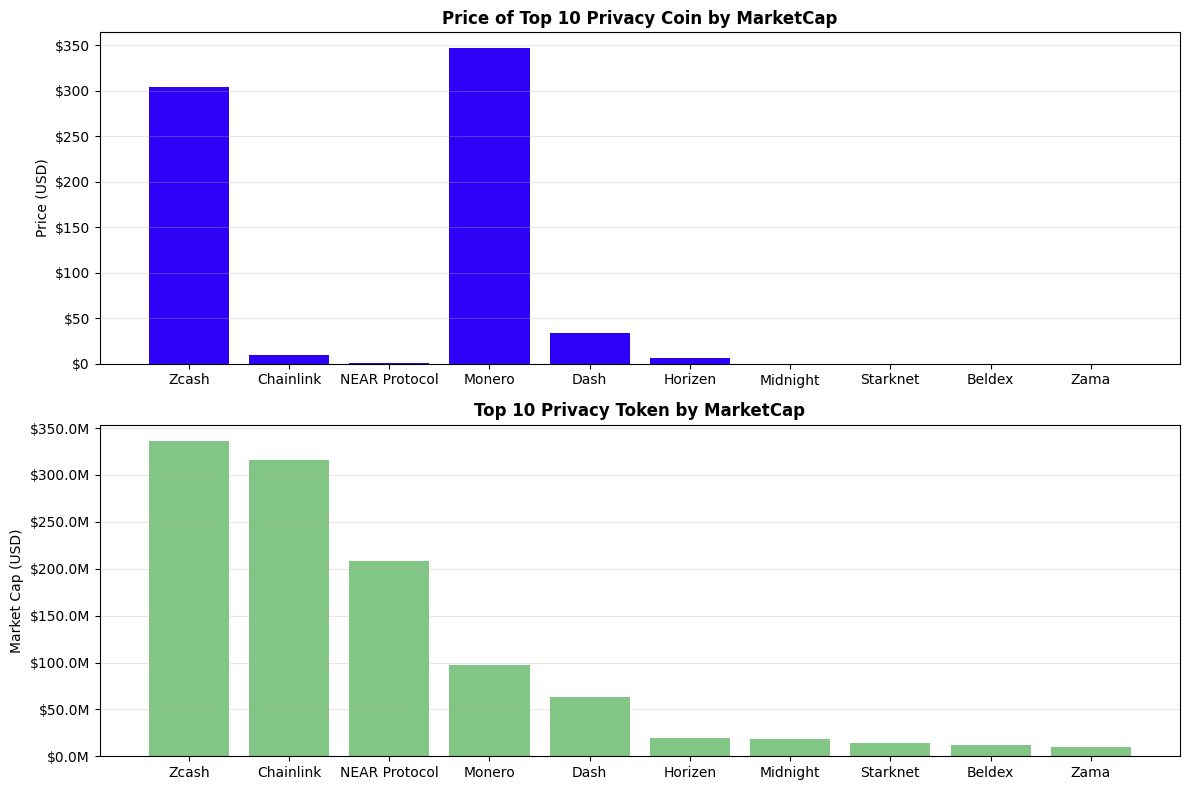

Chart saved as Top_10_privacy_token.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
 
# --- Top chart: Price ---
axes[0].bar(top_10_privacy["Name"], top_10_privacy["Price"],
             color="#2E01F7", linewidth=2)
axes[0].set_title("Price of Top 10 Privacy Coin by MarketCap", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.3, axis="y")
 
# --- Bottom chart: Volume ---
axes[1].bar(top_10_privacy["Name"], top_10_privacy["Market Cap"],
            color="#4CAF50", alpha=0.7)
axes[1].set_title("Top 10 Privacy Token by MarketCap", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Market Cap (USD)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
axes[1].grid(True, alpha=0.3, axis="y")
 
plt.tight_layout()
plt.savefig("Top_10_privacy_token.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as Top_10_privacy_token.png")

# Part 2: Scrapping Bitcoin Treasuries using Selenium

In [17]:
#importing needed libraries

import time

# HTTPS and HTML parsing
import requests
from bs4 import BeautifulSoup

#browser automation (selenium)
from selenium import webdriver #this is used to control the browser and perform actions like clicking, typing, etc.
from selenium.webdriver.chrome.service import Service #this is used to configure chrome webdriver
from selenium.webdriver.chrome.options import Options #this is used to configure chrome options and behaviour (managing starting and running of the browser)
from selenium.webdriver.common.by import By #this is used to specify how to locate elements on the webpage
from selenium.webdriver.support.ui import WebDriverWait #this is used to wait for certain conditions to be met before proceeding with the script
from selenium.webdriver.support import expected_conditions as EC #this is used to specify the conditions to wait for (e.g., presence of an element, visibility of an element, etc.)
from webdriver_manager.chrome import ChromeDriverManager #this is used to automatically manage the chromedriver binary and version compatibility with the installed Chrome browser

# data handling
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [18]:
# Configuring chrome options {Launch a headless browser}
chrome_options = Options()
chrome_options.add_argument("--headless") #this option allows us to run the browser in headless mode (without opening a visible window)
chrome_options.add_argument("--no-sandbox") #this option is used to disable the sandbox security feature (useful in certain environments like Docker)
chrome_options.add_argument("--disable-dev-shm-usage") #this option is used to avoid issues with limited shared memory in certain environments (like Docker)
chrome_options.add_argument("--disable-gpu") #this option is used to disable GPU hardware acceleration and is often necessary when running in headless mode to avoid issues with rendering
chrome_options.add_argument("--window-size=1920,1080") #this option sets the window size for the headless browser (important for ensuring that elements are rendered correctly and can be interacted with)

# A realistic User-Agent prevents some anti-bot measures that block requests from scripts. 
chrome_options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/122.0.0.0 Safari/537.36"
)

service = Service(ChromeDriverManager().install()) #this line sets up the ChromeDriver service using webdriver_manager to automatically handle the driver installation and version compatibility with the installed Chrome browser
driver = webdriver.Chrome(service=service, options=chrome_options) #this line initializes the Chrome WebDriver with the specified service and options, allowing us to control the browser for web scraping tasks.
print("Browser launched successfully!")
print(f"Chrome version: {driver.capabilities['browserVersion']}") #this line prints the version of Chrome being used by the WebDriver, which can be useful for debugging and ensuring compatibility with the target website.

Browser launched successfully!
Chrome version: 147.0.7727.55


In [19]:
#Using Selenium to load the webpage and render JavaScript content

from random import uniform #to genearate random numbers to use in time

TARGET_URL = "https://bitcointreasuries.net/"

driver.get(TARGET_URL) #this line instructs the WebDriver to navigate to the specified URL, allowing us to load the webpage and interact with its content for scraping purposes.

wait = WebDriverWait(driver, 20) #this line creates a WebDriverWait object that will be used to wait for certain conditions to be met before proceeding with the script. 
#The timeout is set to 20 seconds, meaning that if the specified condition is not met within this time frame, a TimeoutException will be raised.

time.sleep(uniform(1,5)) #this line causes the script to pause for a uniform time between 1 and 5 seconds, allowing time for the webpage to fully load and render its content before we attempt to interact with it or scrape data from it. This can help prevent issues with elements not being found or interactions failing due to the page not being ready.

print("Page loaded and data rendered successfully!")
print("Current URL:", driver.current_url) #this line prints the current URL of the webpage that the WebDriver is on, which can be useful for verifying that we have navigated to the correct page and for debugging purposes.
print("Page title:", driver.title) #this line prints the title of the current webpage, which can be useful for verifying that we have loaded the correct page and for debugging purposes. The title is typically displayed in the browser tab and can provide context about the content of the page.    

Page loaded and data rendered successfully!
Current URL: https://bitcointreasuries.net/
Page title: BitcoinTreasuries.NET - Top Bitcoin Treasury Companies


In [20]:
# using beautifulsoup to parse the rendered HTML content

rendered_html = driver.page_source #this line retrieves the HTML source code of the currently loaded webpage after it has been rendered by the browser, allowing us to access the fully rendered content for parsing and scraping purposes.

soup_bt = BeautifulSoup(rendered_html, "lxml") #this line creates a BeautifulSoup object by parsing the rendered HTML content using the "lxml" parser. This allows us to navigate and search the HTML structure of the webpage to extract the desired data.

tables = soup_bt.find_all("table") #this line searches the parsed HTML for all occurrences of <table> elements and assigns it to the variable 'table'. This is typically used when we want to extract data from all table on the webpage, and we can further navigate this 'table' object to access its rows, columns, and cell data.

if tables:
    print("Tables found successfully!")
    print(f"Total tables found: {len(tables)}")

    # loop through each table
    for i, table in enumerate(tables):
        print(f"\nProcessing table {i+1}")
        rows = table.find_all("tr")
        print(f"Rows found: {len(rows)} rows (including table header)")
    
else:
    print(f"No table found. The page may not be fully rendered")
    print("Try increasing the sleep time")

Tables found successfully!
Total tables found: 4

Processing table 1
Rows found: 35 rows (including table header)

Processing table 2
Rows found: 35 rows (including table header)

Processing table 3
Rows found: 35 rows (including table header)

Processing table 4
Rows found: 206 rows (including table header)


In [21]:
from selenium import webdriver

options = webdriver.ChromeOptions()
options.add_argument("--headless=new")  # modern headless
driver = webdriver.Chrome(options=options)

In [22]:
public_treasure = []


if len(tables) >= 4:
    table = tables[3]  # select table 4

    thead = table.find("thead")
    if thead:
        headers_row = thead.find_all("th")
        column_names = [h.get_text(strip=True) for h in headers_row]
        column_names.insert(1, "Country")
        print("Fixed columns:", column_names)

    tbody = table.find("tbody")
    if tbody:
        for row in tbody.find_all("tr"):
            cells = row.find_all("td")
    
            if len(cells) < 2:
                continue

            cell_values = [c.get_text(separator=" ", strip=True) for c in cells]

            # clean first column (extract rank only)
            rank = cell_values[0].split()[0]

            if not rank.isdigit():
                continue

            cell_values[0] = rank  # replace with clean rank

            public_treasure.append(cell_values)

    print(f"Extracted {len(public_treasure)} company rows")

    if public_treasure:
        print("Sample row:", public_treasure[0])

else:
    print("Table 4 not found!")

Fixed columns: ['#', 'Country', 'Name', 'Bitcoin', 'In USD', 'Market Cap', 'Enterprise Value', 'BTC/Share', 'Cost Basis', 'NgU', 'mNAV', '/M.Cap', '/21M']


Extracted 204 company rows
Sample row: ['1', '🇺🇸', 'Strategy MSTR Buy', '₿ 780,897', '$58,348M', '$55,260M', '$**,***M', '*.********', '$**,***M', '*.**x', '*.***', '***.*%', '3.719%']


In [23]:
#build a dataframe from the scrapped data and select only the needed columns

cleaned_data = []

for row in public_treasure:
    cleaned_data.append([
        row[0],  # #
        row[1],  # country
        row[2],  # name
        row[3],  # bitcoin held
        row[4],  # value usd
        row[-1]  # last metric (example)
    ])

column_names = ['#', 'Country', 'Name of Organization', 'Bitcoin Held', 'Value USD', '% of 21M']

df_public = pd.DataFrame(cleaned_data, columns=column_names)

print(f"DataFrame shape: {df_public.shape}")
df_public

DataFrame shape: (204, 6)


,#,Country,Name of Organization,Bitcoin Held,Value USD,% of 21M
0,1,🇺🇸,Strategy MSTR Buy,"₿ 780,897","$58,348M",3.719%
1,2,🇺🇸,Twenty One Capital XXI,"₿ 43,514","$3,251M",0.207%
2,3,🇯🇵,Metaplanet Inc. MPJPY,"₿ 40,177","$3,002M",0.191%
3,4,🇺🇸,"MARA Holdings, Inc. MARA Buy","₿ 38,689","$2,891M",0.184%
4,5,🇺🇸,Bitcoin Standard Treasury Company CEPO,"₿ 30,021","$2,243M",0.143%
...,...,...,...,...,...,...
199,200,🇺🇸,BTCS Inc. BTCS,₿ 0,$0M,0.000%
200,201,🇺🇸,Semler Scientific SMLR,₿ 0,$0M,0.000%
201,202,🇸🇬,Genius Group GNS,₿ 0,$0M,0.000%
202,203,🇸🇬,Bitdeer Technologies Group BTDR,₿ 0,$0M,0.000%


In [24]:
#saving as CSV file

df_public.to_csv("bitcoin_public_treasury_raw.csv", index=False)
print('Saved: bitcoin_public_treasury_raw.csv')

Saved: bitcoin_public_treasury_raw.csv


In [25]:
#quiting our driver
driver.quit()
print("Browser closed!")

Browser closed!


### Now doing comparative analysis on the data scrapped and what we have scrapped before private

In [27]:
#import the data back
import pandas as pd

public = pd.read_csv("bitcoin_public_treasury_raw.csv")
private = pd.read_csv("bitcoin_private_treasury_raw.csv")

print(f'Data Structure of Public and Private Bitcoin Treasuries:')
print(public.shape, private.shape)

#convert all the entries to lowecase so we will be able to compare easily withou 
public.columns = public.columns.str.lower()
private.columns = private.columns.str.lower()

print(f'Public Treasuries Data:')
public.head()

print(f'Private Treasuries Data:')
private.head()

Data Structure of Public and Private Bitcoin Treasuries:
(204, 6) (73, 6)
Public Treasuries Data:
Private Treasuries Data:


,#,country,name of organization,bitcoin held,value in usd,% of 21m
0,1,🇺🇸,Block.one,"₿ 164,000","$11,388M",0.781%
1,2,🇻🇬,Tether Holdings Limited,"₿ 96,184","$6,679M",0.458%
2,3,🇺🇸,Stone Ridge Holdings Group,"₿ 10,000",$694M,0.048%
3,4,🇺🇸,SpaceX 🥬 🙌,"₿ 8,285",$575M,0.039%
4,5,🇨🇭,The Tezos Foundation,"₿ 2,903",$202M,0.014%


In [28]:
#standardizing company name and bitcoin holdings values

public["name of organization"] = public["name of organization"].str.strip().str.lower()
private["name of organization"] = private["name of organization"].str.strip().str.lower()

public["bitcoin held"] = (
    public["bitcoin held"]
    .astype(str)
    .str.replace(",", "")
    .str.extract(r"([\d\.]+)")[0]
    .astype(float)
)

private["bitcoin held"] = (
    private["bitcoin held"]
    .astype(str)
    .str.replace(",", "")
    .str.extract(r"([\d\.]+)")[0]
    .astype(float)
)

public.dtypes
private.dtypes

#                         int64
country                     str
name of organization        str
bitcoin held            float64
value in usd                str
% of 21m                    str
dtype: object

In [29]:
public.head()

,#,country,name of organization,bitcoin held,value usd,% of 21m
0,1,🇺🇸,strategy mstr buy,780897.0,"$58,348M",3.719%
1,2,🇺🇸,twenty one capital xxi,43514.0,"$3,251M",0.207%
2,3,🇯🇵,metaplanet inc. mpjpy,40177.0,"$3,002M",0.191%
3,4,🇺🇸,"mara holdings, inc. mara buy",38689.0,"$2,891M",0.184%
4,5,🇺🇸,bitcoin standard treasury company cepo,30021.0,"$2,243M",0.143%


### Bitcoin Held by each sector

In [30]:

public_total = public["bitcoin held"].sum()
private_total = private["bitcoin held"].sum()

print(f"Public BTC Total: {public_total:,.2f} BTC")
print(f"Private BTC Total: {private_total:,.2f} BTC")

Public BTC Total: 1,177,660.30 BTC
Private BTC Total: 288,014.10 BTC


### How many comapany appears in both Sector

In [31]:
common_companies = set(public["name of organization"]).intersection(set(private["name of organization"]))

print("Number of overlapping companies:", len(common_companies))
print(common_companies)

Number of overlapping companies: 0
set()


### Which country has the most compnies in both lists

In [32]:
combined = pd.concat([public, private])  #combining both data
country_btc = combined.groupby("country")["bitcoin held"].sum().sort_values(ascending=False)
print(country_btc.head(10))

country
🇺🇸    1263248.3
🇻🇬      96196.0
🇯🇵      46165.0
🇨🇳       9197.0
🇨🇦       7697.1
🇭🇰       5825.0
🇫🇷       5464.0
🇧🇷       4328.0
🇩🇪       4221.0
🇬🇧       4111.0
Name: bitcoin held, dtype: float64


## Chart combining both data

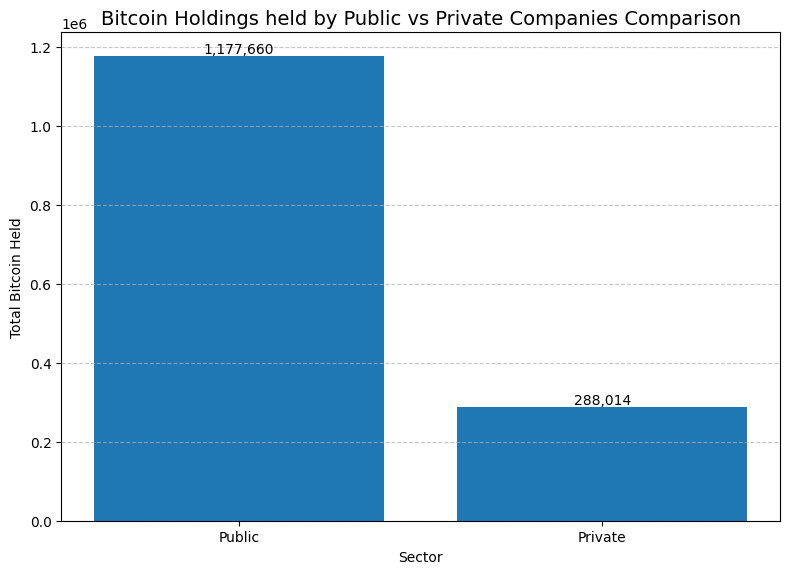

In [33]:
import matplotlib.pyplot as plt

# prepare data
sectors = ["Public", "Private"]
values = [public_total, private_total]

plt.figure(figsize=(8, 6))

bars = plt.bar(sectors, values)

# Title and labels
plt.title("Bitcoin Holdings held by Public vs Private Companies Comparison", fontsize=14)
plt.xlabel("Sector")
plt.ylabel("Total Bitcoin Held")

# Add grid (helps readability)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",   # format with commas
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [34]:
public['name of organization']

0                           strategy mstr buy
1                      twenty one capital xxi
2                       metaplanet inc. mpjpy
3                mara holdings, inc. mara buy
4      bitcoin standard treasury company cepo
                        ...                  
199                            btcs inc. btcs
200                    semler scientific smlr
201                          genius group gns
202           bitdeer technologies group btdr
203                   vault ventures plc vult
Name: name of organization, Length: 204, dtype: str